#***Phase 1: Business Understanding***

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Search for the file

import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'loan_data.csv':
            print(os.path.join(root, file))

/content/drive/MyDrive/Financial-Loan-Default-Prediction/Data/loan_data.csv


In [4]:
# Read the CSV

df = pd.read_csv('/content/drive/MyDrive/Financial-Loan-Default-Prediction/Data/loan_data.csv', nrows=200000, low_memory=False)

print("Data loaded successfully")

Data loaded successfully


In [5]:
df.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,68476668,NaN,20000.0,20000.0,20000.0,36 months,9.17,637.58,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,67275481,NaN,20000.0,20000.0,20000.0,36 months,8.49,631.26,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
8,68466926,NaN,10000.0,10000.0,10000.0,36 months,6.49,306.45,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,68616873,NaN,8000.0,8000.0,8000.0,36 months,11.48,263.74,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Shape

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 200000
Columns: 151


In [7]:
df.columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [8]:
columns_needed = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade',
                  'sub_grade',  'emp_length', 'home_ownership', 'annual_inc',
                  'verification_status','purpose', 'dti','fico_range_low', 'fico_range_high', 'loan_status',]


df = pd.read_csv("/content/drive/MyDrive/Financial-Loan-Default-Prediction/Data/loan_data.csv",
                 usecols=columns_needed, nrows=200000)


In [9]:
df.head(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,fico_range_low,fico_range_high
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,Fully Paid,debt_consolidation,5.91,675.0,679.0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Fully Paid,small_business,16.06,715.0,719.0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,Fully Paid,home_improvement,10.78,695.0,699.0
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,Current,debt_consolidation,17.06,785.0,789.0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,Fully Paid,major_purchase,25.37,695.0,699.0


In [10]:
df.shape

(200000, 15)

In [11]:
# Saving to drive

# df.to_csv("/content/drive/MyDrive/Financial-Loan-Default-Prediction/Data/loan_data_200k.csv", index=False )

# ***Phase 2: Data Understanding***

In [12]:
df

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,fico_range_low,fico_range_high
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,Fully Paid,debt_consolidation,5.91,675.0,679.0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Fully Paid,small_business,16.06,715.0,719.0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,Fully Paid,home_improvement,10.78,695.0,699.0
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,Current,debt_consolidation,17.06,785.0,789.0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,Fully Paid,major_purchase,25.37,695.0,699.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,12000.0,36 months,12.69,402.54,C,C2,1 year,RENT,85000.0,Source Verified,Fully Paid,credit_card,9.82,665.0,669.0
199996,21000.0,36 months,12.29,700.42,C,C1,8 years,RENT,80000.0,Source Verified,Fully Paid,debt_consolidation,13.62,665.0,669.0
199997,27500.0,60 months,14.65,649.19,C,C5,10+ years,RENT,55000.0,Not Verified,Fully Paid,credit_card,16.23,695.0,699.0
199998,7000.0,36 months,10.99,229.14,B,B4,7 years,MORTGAGE,40000.0,Verified,Fully Paid,debt_consolidation,25.29,685.0,689.0


In [13]:
df.dtypes

,0
loan_amnt,float64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_length,object
home_ownership,object
annual_inc,float64
verification_status,object


In [14]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_length,12103
home_ownership,0
annual_inc,0
verification_status,0


# ***Phase 3: Data Cleaning***

In [15]:
df = df.dropna(subset=["dti"])

In [16]:
# Fixing missing values

df["emp_length"] = df["emp_length"].fillna("Not Disclosed")

In [17]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_length,0
home_ownership,0
annual_inc,0
verification_status,0


In [18]:
# Check Duplicate

df.duplicated().sum()

np.int64(0)

In [19]:
# Outlier Check
# Annual_inc = 9000000
# dti = 999

df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high
count,199998.000000,199998.000000,199998.000000,1.999980e+05,199998.000000,199998.000000,199998.000000
mean,15278.190032,12.361738,441.384370,7.815159e+04,19.164467,694.601446,698.601561
std,8651.132467,4.242108,247.051599,8.051365e+04,9.157581,30.769045,30.769609
min,1000.000000,5.320000,14.770000,1.200000e+03,0.000000,660.000000,664.000000
25%,8500.000000,9.170000,261.880000,4.758125e+04,12.540000,670.000000,674.000000
50%,14000.000000,12.290000,383.810000,6.500000e+04,18.610000,685.000000,689.000000
75%,20000.000000,14.650000,580.730000,9.340000e+04,25.410000,710.000000,714.000000
max,35000.000000,28.990000,1445.460000,9.000000e+06,999.000000,845.000000,850.000000


In [20]:
(df["dti"]>100).sum()

np.int64(9)

In [21]:
df = df[df["dti"] <= 100]

In [22]:
df.shape

(199989, 15)

In [23]:
df["annual_inc"].quantile(0.99)

np.float64(260834.55999999912)

In [24]:
(df["annual_inc"] > 260832.55).sum()

np.int64(2000)

In [25]:
# Capping the annual_inc outliers
# Means, any value above 2,60,834 to exactly same 2,60,834

df["annual_inc"] = df["annual_inc"].clip(upper=260834.55)

In [26]:
df["annual_inc"].max()

260834.55

# ***Phase 4: Exploratory Data Analysis (EDA)***

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# Target Column

df["loan_status"].value_counts()


,count
loan_status,
Fully Paid,140983
Charged Off,35089
Current,22636
Late (31-120 days),785
In Grace Period,347
Late (16-30 days),148
Default,1


In [29]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

In [30]:
df["loan_status"].value_counts()

,count
loan_status,
Fully Paid,140983
Charged Off,35089


In [31]:
df.shape

(176072, 15)

In [32]:
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

In [33]:
# clean data, saving to drive

# df.to_csv("/content/drive/MyDrive/Financial-Loan-Default-Prediction/Data/loan_data_clean.csv", index=False )

In [34]:
df["default"].value_counts()

,count
default,
0,140983
1,35089


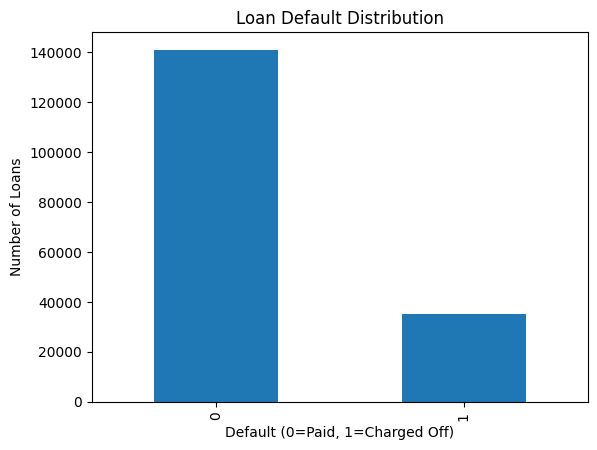

In [35]:
df["default"].value_counts().plot(kind="bar")
plt.title("Loan Default Distribution")
plt.xlabel("Default (0=Paid, 1=Charged Off)")
plt.ylabel("Number of Loans")
plt.show()

**Insight:** Most loans (about 80%) were fully paid, while about
20% were charged off (defaulted).

This shows the bank/investors face roughly a 1 in 5 risk of loan default.

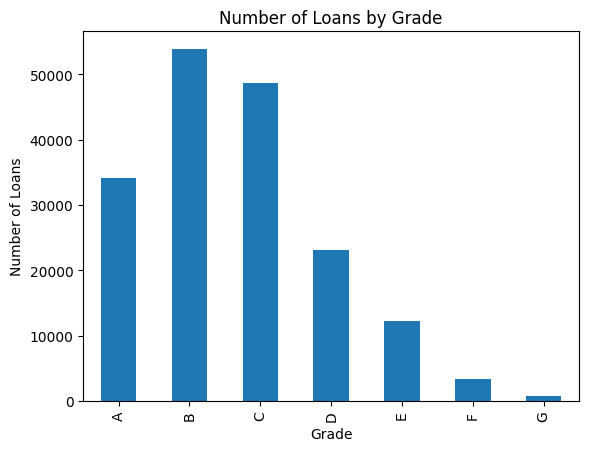

In [36]:
df["grade"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Loans by Grade")
plt.xlabel("Grade")
plt.ylabel("Number of Loans")
plt.show()

**Insight:** Most loans fall in B and C grade categories,

with very few loans in the riskiest grades (F and G).

In [37]:
df.groupby("grade")["default"].mean()

,default
grade,
A,0.052874
B,0.127660
C,0.230072
D,0.332755
E,0.433149
F,0.522501
G,0.579355


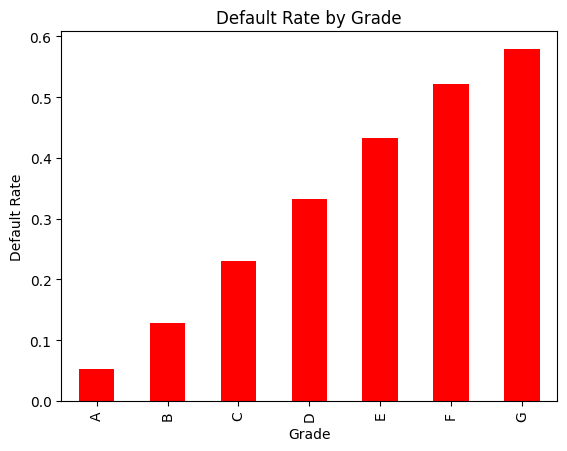

In [38]:
df.groupby("grade")["default"].mean().plot(kind="bar", color='red')
plt.title("Default Rate by Grade")
plt.xlabel("Grade")
plt.ylabel("Default Rate")
plt.show()

**Insight:** Default rate increases steadly from Grade A (5.3%) to Grade G (57.9%).

Lending Club's grading system is a strong and reliable predictor of reliable of default risk.

In [39]:
# spliting a number column into ranges with the help of pd.cut

df["income_group"] = pd.cut(df["annual_inc"], bins=[0, 40000, 80000, 120000, 300000], labels=["Low", "Medium", "High", "Very High"])

In [40]:
# People who earn less money per year default more 22.6%
# People who earn higher income per year default less 14.4%

df.groupby("income_group")["default"].mean()

,default
income_group,
Low,0.226678
Medium,0.212145
High,0.176446
Very High,0.144846


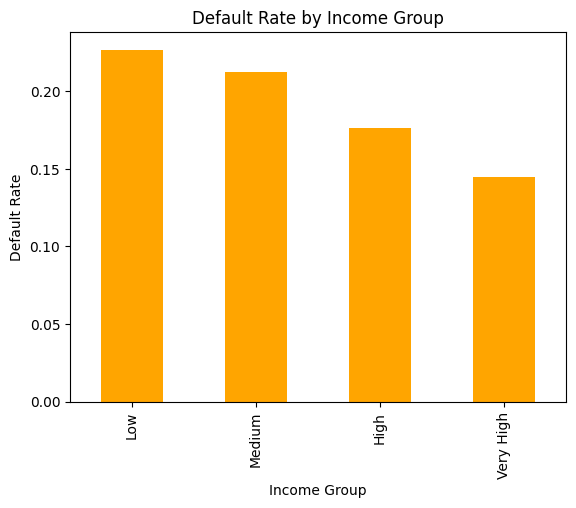

In [41]:
df.groupby("income_group")["default"].mean().plot(kind="bar", color="orange")
plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate")
plt.show()

**Insight:** Default rate decreases as income increases - from

22.7% (Low Income) to 14.5% (Very High Income).

In [42]:
# small_business default 29.39% higher

df.groupby("purpose")["default"].mean().sort_values(ascending=False)

,default
purpose,
small_business,0.293958
renewable_energy,0.280374
house,0.268581
moving,0.224835
debt_consolidation,0.215444
medical,0.208740
other,0.201757
major_purchase,0.187842
vacation,0.181078


In [43]:
# One row only

df[df["purpose"] == "wedding"].shape

(1, 17)

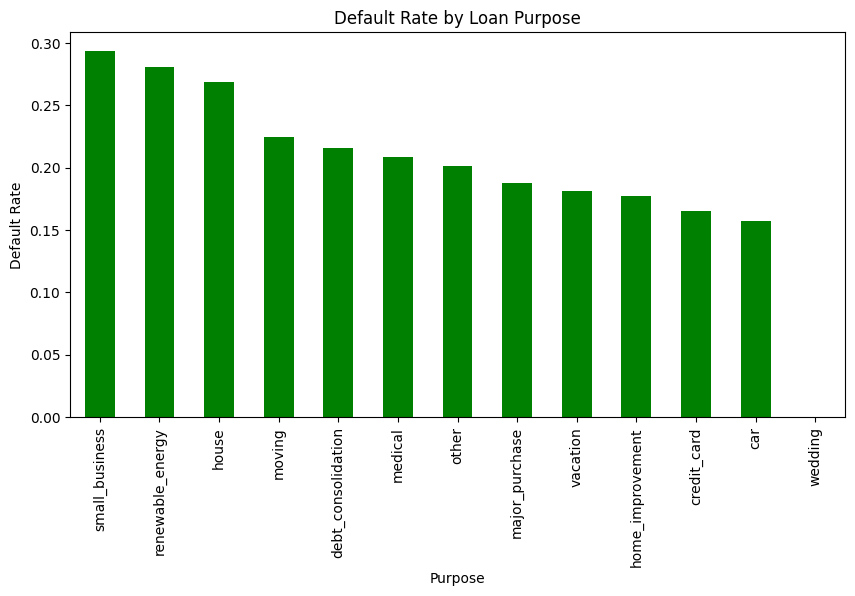

In [44]:
df.groupby("purpose")["default"].mean().sort_values(ascending=False).plot(kind="bar", color="green", figsize=(10,5))
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Purpose")
plt.ylabel("Default Rate")
plt.show()

**Insight:** Small business loans have the highest default rate (29.4%),

while car and credit loans have the lowest (15%-16%). Wedding shows 0% default,

 but this is unreliable due to only 1 row in that category.

In [45]:
# Spliting dti into group

df["dti_group"] = pd.cut(df["dti"], bins=[0, 10, 20, 30, 100], labels=["Low", "Medium", "High", "Very High"])

In [46]:
df.groupby("dti_group")["default"].mean()

,default
dti_group,
Low,0.139296
Medium,0.173492
High,0.225730
Very High,0.300609


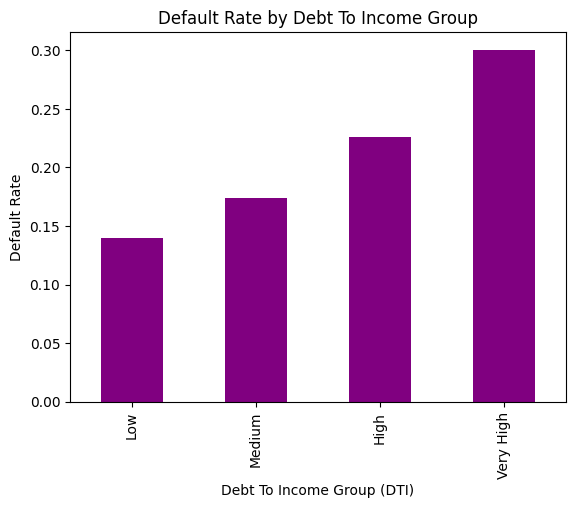

In [47]:
df.groupby("dti_group")["default"].mean().plot(kind="bar", color="purple")
plt.title("Default Rate by Debt To Income Group")
plt.xlabel("Debt To Income Group (DTI)")
plt.ylabel("Default Rate")
plt.show()

**Insight:** As DTI goes up, more people default.

Low DTI group
has 13.9% default. Very high DTI group has 30.1% default.

In [48]:
# Correlation Table

df[["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low", "default"]].corr()

,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,default
loan_amnt,1.000000,0.126372,0.954795,0.491358,0.015398,0.127742,0.066735
int_rate,0.126372,1.000000,0.102991,-0.146658,0.198497,-0.390899,0.308983
installment,0.954795,0.102991,1.000000,0.479674,0.003431,0.093039,0.033806
annual_inc,0.491358,-0.146658,0.479674,1.000000,-0.240569,0.112571,-0.066025
dti,0.015398,0.198497,0.003431,-0.240569,1.000000,-0.058975,0.122131
fico_range_low,0.127742,-0.390899,0.093039,0.112571,-0.058975,1.000000,-0.136511
default,0.066735,0.308983,0.033806,-0.066025,0.122131,-0.136511,1.000000


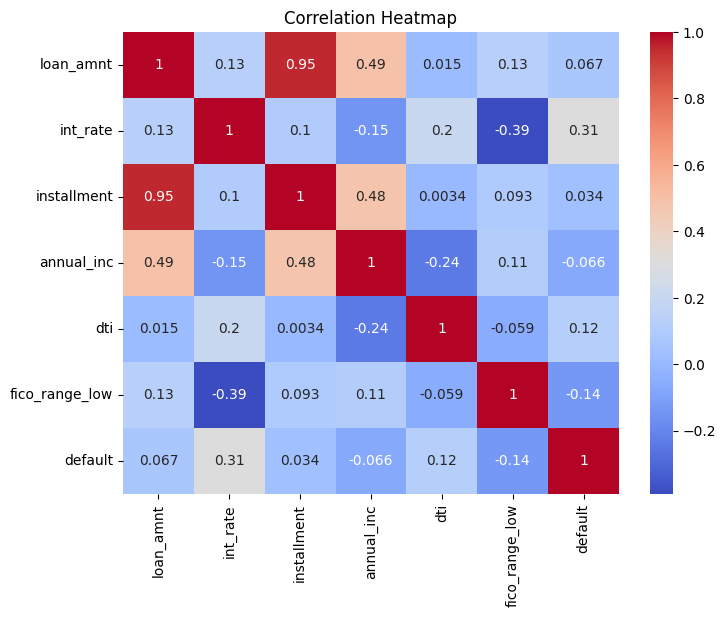

In [49]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low", "default"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Insight:**

> Interst rate has the strongest connection with default (0.31). as interest rate increases, defualt increases a little.

> DTI has a small positive connection (0.12). As DTI increases, default increases a little.

> FICO score has a small negative connection (-0.14), meaning higher credit scores relate to lower default. As FISCO increases, default increases a little.


> AS annual_inc increases, default decreases a tiny bit.


# ***Phase 5: Feature Engineering***

In [50]:
df.dtypes

,0
loan_amnt,float64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_length,object
home_ownership,object
annual_inc,float64
verification_status,object


In [51]:
# Deleting columns we no longer need

df = df.drop(columns=["loan_status", "income_group", "dti_group"])

In [52]:
df.shape

(176072, 15)

### ***Encoding***

> **term** - Ordinal Encoding

> **grade** - Ordinal Encoding

> **sub_grade** - Ordinal Encoding

> **emp_length** - Ordinal Encoding

> **home_ownership** - One Hot Encoding

> **verification_status** - One Hot Encoding

> **purpose** - One Hot Encoding


In [53]:
# Ordinal Encoding

In [54]:
df["term"].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [55]:
df["term"] = df["term"].str.replace(" months", "").astype(int)

In [56]:
df["term"].unique()

array([36, 60])

In [57]:
grade_mapping = {"A":1, "B":2, "C":3, "D":4, "E":5, "F":6, "G":7}
df["grade"] = df["grade"].map(grade_mapping)

In [58]:
df["grade"].unique()

array([3, 2, 6, 1, 5, 4, 7])

In [59]:
df["sub_grade"].unique()

array(['C4', 'C1', 'B4', 'F1', 'C3', 'B2', 'B1', 'A2', 'B5', 'C2', 'E2',
       'A4', 'E3', 'C5', 'A1', 'D4', 'F3', 'D1', 'B3', 'D3', 'D5', 'A5',
       'F2', 'E4', 'D2', 'E1', 'F5', 'E5', 'A3', 'G2', 'G1', 'G3', 'G4',
       'F4', 'G5'], dtype=object)

In [60]:
sub_grades = ['A1','A2','A3','A4','A5', 'B1','B2','B3','B4','B5','C1','C2','C3','C4','C5','D1','D2','D3','D4','D5',
               'E1','E2','E3','E4','E5','F1','F2','F3','F4','F5','G1','G2','G3','G4','G5']

In [61]:
df["sub_grade"] = df["sub_grade"].apply(lambda x: sub_grades.index(x) + 1)

In [62]:
df["sub_grade"].unique()

array([14, 11,  9, 26, 13,  7,  6,  2, 10, 12, 22,  4, 23, 15,  1, 19, 28,
       16,  8, 18, 20,  5, 27, 24, 17, 21, 30, 25,  3, 32, 31, 33, 34, 29,
       35])

In [63]:
df["emp_length"].unique()

array(['10+ years', '3 years', '4 years', '6 years', '7 years', '8 years',
       '2 years', '5 years', '9 years', '< 1 year', '1 year',
       'Not Disclosed'], dtype=object)

In [64]:
emp_mapping = {
  "Not Disclosed": 0,
  "< 1 year": 0.5,
  "1 year": 1,
  "2 years": 2,
  "3 years": 3,
  "4 years": 4,
  "5 years": 5,
  "6 years": 6,
  "7 years": 7,
  "8 years": 8,
  "9 years": 9,
  "10+ years": 10
  }

df["emp_length"] = df["emp_length"].map(emp_mapping)

In [65]:
df['emp_length'].unique()

array([10. ,  3. ,  4. ,  6. ,  7. ,  8. ,  2. ,  5. ,  9. ,  0.5,  1. ,
        0. ])

In [66]:
# One Hot Encoding

In [67]:
df = pd.get_dummies(df, columns=["home_ownership", "verification_status", "purpose"], drop_first=True)

In [68]:
df.shape

(176072, 29)

In [69]:
df.dtypes

,0
loan_amnt,float64
term,int64
int_rate,float64
installment,float64
grade,int64
sub_grade,int64
emp_length,float64
annual_inc,float64
dti,float64
fico_range_low,float64


In [70]:
df.head(3)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,dti,fico_range_low,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,3600.0,36,13.99,123.03,3,14,10.0,55000.0,5.91,675.0,...,False,False,False,False,False,False,False,False,False,False
1,24700.0,36,11.99,820.28,3,11,10.0,65000.0,16.06,715.0,...,False,False,False,False,False,False,False,True,False,False
2,20000.0,60,10.78,432.66,2,9,10.0,63000.0,10.78,695.0,...,True,False,False,False,False,False,False,False,False,False


### ***Feature Scaling***

> loan amnt

> int_rate

> installment

> annual_inc

> dti

> fico_range_low

> fico_range_high

In [71]:
from sklearn.preprocessing import StandardScaler

In [72]:
scaler = StandardScaler()
cols_to_scale = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low", "fico_range_high"]
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [73]:
df[cols_to_scale].describe()

,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high
count,1.760720e+05,1.760720e+05,1.760720e+05,1.760720e+05,1.760720e+05,1.760720e+05,1.760720e+05
mean,4.519787e-17,2.621476e-16,-1.040358e-16,3.185642e-16,2.605334e-16,-1.284911e-15,1.114450e-15
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-1.580740e+00,-1.604338e+00,-1.658670e+00,-1.658724e+00,-2.176454e+00,-1.111656e+00,-1.111637e+00
25%,-7.683146e-01,-8.812259e-01,-7.294941e-01,-6.827683e-01,-7.586504e-01,-7.897038e-01,-7.896919e-01
50%,-2.547455e-01,-2.814277e-02,-2.401048e-01,-2.433571e-01,-6.414562e-02,-3.067760e-01,-3.067740e-01
75%,6.244152e-01,6.004448e-01,5.653297e-01,3.810694e-01,7.132852e-01,4.981036e-01,4.980893e-01
max,2.365327e+00,3.989146e+00,3.960176e+00,4.285690e+00,8.189290e+00,4.844454e+00,4.876545e+00


In [74]:
# Data is ready for the model

# df.to_csv("/content/drive/MyDrive/Financial-Loan-Default-Prediction/Data/loan_data_model_ready.csv", index=False)

# ***Phase 6: Machine Learning - Logistic Regression***

In [75]:
X = df.drop(columns=["default"])
y = df["default"]

In [76]:
X.shape

(176072, 28)

In [77]:
y.shape

(176072,)

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [79]:
print(X_train.shape)
print(X_test.shape)

(140857, 28)
(35215, 28)


In [80]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

In [81]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [82]:
# Making prediction on text data

y_pred = model.predict(X_test)

In [83]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [84]:
import numpy as np
np.unique(y_pred, return_counts=True)

(array([0, 1]), array([33512,  1703]))

In [85]:
y_test.value_counts()

,count
default,
0,28253
1,6962


**Confirming**

We trained the model using 80% of data (X_train, y_train)
We tested it on the remaining 20% (X_test),

comparing its guesses against the real answers (y_test)
The model only flagged 1,703 people as "will default"


But in reality, about 6,962 people actually defaulted
This means the model is missing most real defaulters

it's not performing well for our actual business goal

### ***Retrain the model with class_weight="balanced"***

In [86]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [87]:
# Predicting again

y_pred = model.predict(X_test)
np.unique(y_pred, return_counts=True)

(array([0, 1]), array([21807, 13408]))

In [88]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[19400,  8853],
       [ 2407,  4555]])

# ***Phase 6: Random Forest Comparision***

In [91]:
from sklearn.ensemble import RandomForestClassifier

In [92]:
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [93]:
y_pred_rf = rf_model.predict(X_test)

# ***Phase 7: Model Evaluation***

In [89]:
from sklearn.metrics import classification_report

In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.69      0.78     28253
           1       0.34      0.65      0.45      6962

    accuracy                           0.68     35215
   macro avg       0.61      0.67      0.61     35215
weighted avg       0.78      0.68      0.71     35215



In [95]:
# Random Forest Classification

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89     28253
           1       0.51      0.14      0.21      6962

    accuracy                           0.80     35215
   macro avg       0.66      0.55      0.55     35215
weighted avg       0.76      0.80      0.75     35215



## ***Model Evaluation Summary:***


**Approach:** Trained Logistic Regression and Random Forest, both with class_weight='balanced'

to handle class imbalance (20% default rate).


**Results:**
> **Logistic Regression:** 67% accuracy, 65% recall on defaults.

> **Random Forest:** 80% accuracy, only 14% recall on defaults.

**Key Finding:** Random Forest's higher accuracy was misleading - it mostly predicted "safe," missing most real defaulters.

Logistic Regression caught far more actual defaults despite lower accuracy.
Conclusion: Logistic Regression selected as final model,

 since recall (catching real risk) matters more than accuracy for this business problem.